# Modelos basados en árboles: comparación temporal con Optuna

Ahora comparo Random Forest, XGBoost, LightGBM y CatBoost, manteniendo los dos escenarios de score y la función de ganancia como objetivo.

La diferencia principal respecto del notebook 03 es que acá hay búsqueda de hiperparámetros. Para no evaluar un modelo sobre los mismos folds usados para ajustarlo, uso una validación temporal anidada: Optuna ve solamente folds anteriores y el candidato elegido se evalúa en el fold siguiente

## 1. Setup

In [1]:
from pathlib import Path
import importlib
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from IPython.display import display
from tqdm.auto import tqdm

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import auc, precision_recall_curve, roc_auc_score, roc_curve

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier, Pool

optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams["figure.figsize"] = (7, 3.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Recargo estos módulos por si fueron modificados mientras el kernel seguía abierto.
import src.data as data_module
import src.evaluation as evaluation_module
import src.features as features_module
importlib.reload(data_module)
importlib.reload(evaluation_module)
importlib.reload(features_module)

from src.business import ganancia_por_operacion, ganancia_total, umbral_aprobacion
from src.modeling import USAR_GPU
from src.data import TARGET, DEFAULT_DATA_PATH, DEFAULT_PROCESSED_DIR, cargar_datos, convertir_fecha
from src.evaluation import (
    ajustar_calibrador_sigmoide,
    aplicar_calibrador,
    mejor_umbral_ganancia,
    metricas_decision,
    metricas_probabilidad,
    transformar_logit,
)
from src.features import (
    CATEGORICAS_ARBOL,
    crear_features_arbol,
    preparar_categoricas_por_train,
)
from src.validation import mascaras_desarrollo_test, mascaras_fold, validar_folds

UMBRAL_ECONOMICO = umbral_aprobacion()
RANDOM_SEED = 42
N_TRIALS = 20
SEMILLAS_EVALUACION = [42, 43, 44]
FOLDS_EXTERNOS = [2, 3]

FOLDS_PATH = DEFAULT_PROCESSED_DIR / "validation_folds.csv"
RESULTADOS_BASICOS_PATH = DEFAULT_PROCESSED_DIR / "resultados_modelado_basico.csv"
OPTUNA_DB_PATH = DEFAULT_PROCESSED_DIR / "optuna_arboles.db"
PARAMS_PATH = DEFAULT_PROCESSED_DIR / "mejores_params_arbol.json"
STORAGE_URL = f"sqlite:///{OPTUNA_DB_PATH.as_posix()}"

print(f"Umbral económico: {UMBRAL_ECONOMICO:.2f}")
print(f"Trials máximos por estudio: {N_TRIALS}")

c:\Users\cfede\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Umbral económico: 0.20
Trials máximos por estudio: 20


In [2]:
df = cargar_datos(DEFAULT_DATA_PATH)
fecha = convertir_fecha(df["fecha"])
fecha_origen = fecha.min().normalize()

columnas_fecha = ["train_start", "train_end", "validation_start", "validation_end"]
folds = pd.read_csv(FOLDS_PATH, parse_dates=columnas_fecha)
es_desarrollo, es_test = mascaras_desarrollo_test(fecha)
chequeos = validar_folds(fecha, folds, es_test)

X_por_escenario = {
    "sin_score": crear_features_arbol(df, incluir_score=False, fecha_origen=fecha_origen),
    "con_score": crear_features_arbol(df, incluir_score=True, fecha_origen=fecha_origen),
}
y = df[TARGET]
monto = df["monto"]

print(f"Desarrollo: {es_desarrollo.sum():,} filas")
print(f"Test bloqueado: {es_test.sum():,} filas")
print({nombre: X.shape[1] for nombre, X in X_por_escenario.items()})
chequeos[["n_train", "n_validacion"]]

Desarrollo: 121,014 filas
Test bloqueado: 28,986 filas
{'sin_score': 21, 'con_score': 22}


,n_train,n_validacion
fold,,
1,60424,16537
2,76961,20282
3,97243,23771


## 2. Features y preprocesamiento

Los árboles reciben las numéricas sin logs, escalado ni recorte de colas. A partir de fecha se crean hora, día de semana y días desde el inicio. Las categóricas conservan su identidad y la ausencia entra como el nivel faltante.

### 2.1. Categóricas y faltantes

- XGBoost, LightGBM y CatBoost reciben las categóricas mediante su soporte nativo.
- En cada fold, los niveles categóricos se aprenden solamente con train. Si aparece un valor nuevo en validación, se representa como desconocida.
- Random Forest usa one-hot para a, g, o y p. El one-hot evita imponer un orden artificial entre categorías.
- Para j en Random Forest uso target encoding con cross-fitting interno sobre train. Los niveles de validación NO participan del cálculo.
- Los boosting reciben los NaN numéricos directamente. En Random Forest mantengo mediana más indicadores de ausencia para conservar una representación simple y consistente.

Las versiones actuales de Random Forest pueden manejar NaN numéricos, pero la imputación sigue siendo útil acá porque comparte un único preprocesamiento denso con los encodings categóricos. Es una decisión de esta comparación.

## 3. Validación temporal anidada

Optuna selecciona parámetros usando únicamente folds anteriores:

- Para evaluar en el fold 2, el fold 1 funciona como validación interna.
- Para evaluar en el fold 3, los folds 1 y 2 funcionan como validaciones internas.

Una vez elegida la configuración, el modelo se reentrena con todo el historial anterior al fold externo y se evalúa sobre ese período, que no participó de la búsqueda. El fold 1 no puede ser externo porque no tiene una validación previa para seleccionar hiperparámetros. Cada estudio ejecuta hasta 20 trials y se guarda en SQLite para poder reanudarlo.

No busco class_weight ni scale_pos_weight en esta etapa. El umbral de 20% supone que la salida representa una probabilidad de fraude, y los pesos de clase corren esa escala. No lo decido por analogía con la logística del notebook 3: en árboles reponderar no es solo un corrimiento de escala, también cambia los cortes y los gradientes, así que el efecto sobre el ordenamiento hay que medirlo. Lo verifico de forma empírica en la futura sección 7.1, reponderando y después recalibrando para una comparación justa

In [3]:
def sugerir_params(trial, nombre):
    if nombre == "xgboost":
        return dict(
            n_estimators=trial.suggest_int("n_estimators", 200, 600),
            max_depth=trial.suggest_int("max_depth", 3, 10),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
            min_child_weight=trial.suggest_int("min_child_weight", 1, 12),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        )
    if nombre == "lightgbm":
        return dict(
            n_estimators=trial.suggest_int("n_estimators", 200, 600),
            num_leaves=trial.suggest_int("num_leaves", 15, 255),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            feature_fraction=trial.suggest_float("feature_fraction", 0.6, 1.0),
            bagging_fraction=trial.suggest_float("bagging_fraction", 0.6, 1.0),
            min_child_samples=trial.suggest_int("min_child_samples", 5, 100),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        )
    if nombre == "catboost":
        return dict(
            iterations=trial.suggest_int("iterations", 200, 600),
            depth=trial.suggest_int("depth", 4, 10),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 12.0),
        )
    if nombre == "rf":
        return dict(
            n_estimators=trial.suggest_int("n_estimators", 200, 600),
            max_depth=trial.suggest_int("max_depth", 4, 30),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5]),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 20),
        )
    raise ValueError(nombre)

In [4]:
from src.modeling import ajustar_y_predecir_arbol

### 3.1. ¿Aporta k en los árboles?

Aunque k no aporta en la logística, un árbol podría aprovechar relaciones no lineales. Comparo los cuatro modelos con y sin k, usando tres semillas y dos configuraciones: una modesta y otra de alta capacidad. El delta de ganancia se contrasta con la variación entre semillas. Si no aparece una mejora estable en ninguna familia, k se descarta antes de optimizar.

In [5]:
configs_ablacion = {
    "modesta": {
        "rf": {"n_estimators": 300},
        "xgboost": {"n_estimators": 300},
        "lightgbm": {"n_estimators": 300},
        "catboost": {"iterations": 300},
    },
    "alta_capacidad": {
        "rf": {"n_estimators": 600, "max_depth": 30, "max_features": 0.5, "min_samples_leaf": 1},
        "xgboost": {"n_estimators": 600, "max_depth": 10},
        "lightgbm": {"n_estimators": 600, "num_leaves": 255},
        "catboost": {"iterations": 600, "depth": 10},
    },
}
modelos_candidatos = ["rf", "xgboost", "lightgbm", "catboost"]

X_sin_k = X_por_escenario["con_score"]
X_con_k = crear_features_arbol(
    df, incluir_score=True, fecha_origen=fecha_origen, incluir_k=True
)

filas_ablacion_k = []
for capacidad, params_capacidad in configs_ablacion.items():
    for nombre in modelos_candidatos:
        for semilla in SEMILLAS_EVALUACION:
            ganancia_variante = {}
            for etiqueta, X_datos in [("sin_k", X_sin_k), ("con_k", X_con_k)]:
                ganancia = 0.0
                for _, fold in folds.iterrows():
                    train, validacion = mascaras_fold(fecha, fold)
                    proba = ajustar_y_predecir_arbol(
                        nombre,
                        params_capacidad[nombre],
                        X_datos.loc[train],
                        y.loc[train],
                        X_datos.loc[validacion],
                        semilla=semilla,
                    )
                    ganancia += ganancia_total(
                        y.loc[validacion], monto.loc[validacion], proba < UMBRAL_ECONOMICO
                    )
                ganancia_variante[etiqueta] = ganancia
            filas_ablacion_k.append({
                "capacidad": capacidad,
                "modelo": nombre,
                "semilla": semilla,
                "sin_k": ganancia_variante["sin_k"],
                "con_k": ganancia_variante["con_k"],
                "delta": ganancia_variante["con_k"] - ganancia_variante["sin_k"],
            })

ablacion_k_arbol = pd.DataFrame(filas_ablacion_k)
resumen_ablacion_k_arbol = (
    ablacion_k_arbol.groupby(["capacidad", "modelo"])
    .agg(
        sin_k=("sin_k", "mean"),
        con_k=("con_k", "mean"),
        delta_medio=("delta", "mean"),
        delta_std=("delta", "std"),
        ruido_semillas=("sin_k", "std"),
    )
    .reindex(pd.MultiIndex.from_product(
        [["modesta", "alta_capacidad"], modelos_candidatos],
        names=["capacidad", "modelo"]))
)
resumen_ablacion_k_arbol

c:\Users\cfede\miniconda3\Lib\site-packages\xgboost\core.py:553: UserWarning: [13:16:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


sin_k        con_k  delta_medio  delta_std  \
capacidad      modelo                                                       
modesta        rf       419,671.0025 421,966.8217   2,295.8192 3,353.8844   
               xgboost  397,882.0975 395,813.0400  -2,069.0575     0.0000   
               lightgbm 416,772.3250 412,473.7075  -4,298.6175     0.0000   
               catboost 427,178.6533 423,366.2508  -3,812.4025 2,301.3347   
alta_capacidad rf       416,655.2158 420,235.0267   3,579.8108 2,607.6020   
               xgboost  400,736.2025 399,424.8200  -1,311.3825     0.0000   
               lightgbm 398,516.5375 395,366.5575  -3,149.9800     0.0000   
               catboost 414,965.1658 413,677.7517  -1,287.4142 2,906.8962   

                         ruido_semillas  
capacidad      modelo                    
modesta        rf            2,682.1569  
               xgboost           0.0000  
               lightgbm          0.0000  
               catboost      1,252.0374  
alta_capacidad rf            1,924.0298  
               xgboost           0.0000  
               lightgbm          0.0000  
               catboost        757.9683

k empeora XGBoost, LightGBM y CatBoost en ambas configuraciones. Random Forest muestra deltas positivos, pero dentro o cerca de su variación entre semillas. Como no aparece un beneficio estable, k queda fuera antes de optimizar. La decisión se toma en desarrollo y no se vuelve a comparar en test.

## 4. Optimización con Optuna

Cada estudio corresponde a modelo, escenario de score y fold externo. El objetivo suma la ganancia de los folds internos usando el umbral fijo de 20%. La base SQLite permite interrumpir y continuar el notebook.

In [6]:
MODELOS = ["rf", "xgboost", "lightgbm", "catboost"]


def objetivo(trial, nombre, escenario, outer_fold):
    params = sugerir_params(trial, nombre)
    X = X_por_escenario[escenario]
    ganancia_acumulada = 0.0
    folds_internos = folds.query("fold < @outer_fold")

    for paso, (_, fold) in enumerate(folds_internos.iterrows()):
        train, validacion = mascaras_fold(fecha, fold)
        probabilidad = ajustar_y_predecir_arbol(
            nombre,
            params,
            X.loc[train],
            y.loc[train],
            X.loc[validacion],
        )
        aprobar = probabilidad < UMBRAL_ECONOMICO
        ganancia_acumulada += ganancia_total(
            y.loc[validacion], monto.loc[validacion], aprobar
        )
        trial.report(ganancia_acumulada, step=paso)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return ganancia_acumulada


def correr_estudio(nombre, escenario, outer_fold):
    study_name = f"v3_{nombre}_{escenario}_outer{outer_fold}"
    study = optuna.create_study(
        study_name=study_name,
        storage=STORAGE_URL,
        load_if_exists=True,
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1),
    )
    restantes = max(0, N_TRIALS - len(study.trials))
    if restantes:
        descripcion = f"{nombre} | {escenario} | fold externo {outer_fold}"
        with tqdm(total=restantes, desc=descripcion, leave=False) as barra:
            def actualizar_barra(study, trial):
                barra.update(1)
                completos = [
                    t for t in study.trials
                    if t.state == optuna.trial.TrialState.COMPLETE
                ]
                if completos:
                    barra.set_postfix(mejor=f"{study.best_value:,.0f}")

            study.optimize(
                lambda trial: objetivo(trial, nombre, escenario, outer_fold),
                n_trials=restantes,
                callbacks=[actualizar_barra],
                show_progress_bar=False,
            )
    return study

In [7]:
DEFAULT_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
estudios = {}
mejores_params = {}
filas_estudios = []

for outer_fold in FOLDS_EXTERNOS:
    for escenario in X_por_escenario:
        for nombre in MODELOS:
            clave = (nombre, escenario, outer_fold)
            print(f"Optimizando {nombre} | {escenario} | evaluación fold {outer_fold}")
            study = correr_estudio(nombre, escenario, outer_fold)
            estudios[clave] = study
            mejores_params[clave] = study.best_params
            filas_estudios.append({
                "modelo": nombre,
                "escenario": escenario,
                "outer_fold": outer_fold,
                "mejor_ganancia_interna": study.best_value,
                "n_trials": len(study.trials),
                "n_completos": sum(t.state.name == "COMPLETE" for t in study.trials),
            })

resumen_estudios = pd.DataFrame(filas_estudios)
params_serializables = {
    f"{modelo}|{escenario}|outer{outer}": params
    for (modelo, escenario, outer), params in mejores_params.items()
}
PARAMS_PATH.write_text(
    json.dumps(params_serializables, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
resumen_estudios

Optimizando rf | sin_score | evaluación fold 2
Optimizando xgboost | sin_score | evaluación fold 2
Optimizando lightgbm | sin_score | evaluación fold 2
Optimizando catboost | sin_score | evaluación fold 2
Optimizando rf | con_score | evaluación fold 2
Optimizando xgboost | con_score | evaluación fold 2
Optimizando lightgbm | con_score | evaluación fold 2
Optimizando catboost | con_score | evaluación fold 2
Optimizando rf | sin_score | evaluación fold 3
Optimizando xgboost | sin_score | evaluación fold 3
Optimizando lightgbm | sin_score | evaluación fold 3
Optimizando catboost | sin_score | evaluación fold 3
Optimizando rf | con_score | evaluación fold 3
Optimizando xgboost | con_score | evaluación fold 3
Optimizando lightgbm | con_score | evaluación fold 3
Optimizando catboost | con_score | evaluación fold 3


,modelo,escenario,outer_fold,mejor_ganancia_interna,n_trials,n_completos
0,rf,sin_score,2,"115,604.7325",20,19
1,xgboost,sin_score,2,"115,391.5900",20,20
2,lightgbm,sin_score,2,"116,379.3850",20,20
3,catboost,sin_score,2,"115,502.1950",20,20
4,rf,con_score,2,"117,951.3000",20,20
5,xgboost,con_score,2,"117,225.6575",20,20
6,lightgbm,con_score,2,"118,247.2700",20,20
7,catboost,con_score,2,"118,361.7050",20,20
8,rf,sin_score,3,"246,098.7225",20,13
9,xgboost,sin_score,3,"247,790.1250",20,15


## 5. Evaluación externa antes de calibrar

Cada mejor configuración se reentrena con el train del fold externo y se evalúa en su validación, que Optuna no usó. Repito el ajuste con tres semillas para observar cuánto cambia el resultado por aleatoriedad, CatBoost GPU puede variar ligeramente aun con la misma semilla

In [8]:
resultados_externos = []
predicciones_externas = []

for outer_fold in FOLDS_EXTERNOS:
    fold = folds.loc[folds["fold"].eq(outer_fold)].iloc[0]
    train, validacion = mascaras_fold(fecha, fold)
    y_val = y.loc[validacion]
    monto_val = monto.loc[validacion]
    categorias_train = set(df.loc[train, "j"].dropna().unique())
    j_nueva = ~df.loc[validacion, "j"].isin(categorias_train)

    for escenario, X in X_por_escenario.items():
        for nombre in MODELOS:
            params = mejores_params[(nombre, escenario, outer_fold)]
            for repeticion, semilla in enumerate(SEMILLAS_EVALUACION):
                probabilidad = pd.Series(
                    ajustar_y_predecir_arbol(
                        nombre,
                        params,
                        X.loc[train],
                        y.loc[train],
                        X.loc[validacion],
                        semilla=semilla,
                    ),
                    index=df.index[validacion],
                )
                aprobar = probabilidad < UMBRAL_ECONOMICO
                fila = {
                    "outer_fold": outer_fold,
                    "modelo": nombre,
                    "escenario": escenario,
                    "repeticion": repeticion,
                }
                fila.update(metricas_decision(y_val, monto_val, aprobar))
                fila.update(metricas_probabilidad(y_val, probabilidad))
                resultados_externos.append(fila)

                ganancia_si_aprueba = ganancia_por_operacion(y_val, monto_val)
                predicciones_externas.append(pd.DataFrame({
                    "row_id": y_val.index,
                    "outer_fold": outer_fold,
                    "modelo": nombre,
                    "escenario": escenario,
                    "repeticion": repeticion,
                    "semilla": semilla,
                    "target": y_val,
                    "monto": monto_val,
                    "probabilidad_fraude": probabilidad,
                    "aprobar": aprobar,
                    "j_nueva": j_nueva,
                    "ganancia_realizada": np.where(aprobar, ganancia_si_aprueba, 0.0),
                }))

resultados_externos = pd.DataFrame(resultados_externos)
predicciones_externas = pd.concat(predicciones_externas, ignore_index=True)
resultados_externos.head()

,outer_fold,modelo,escenario,repeticion,ganancia,tasa_aprobacion,fraudes_rechazados,legitimas_rechazadas,roc_auc,pr_auc,brier,prevalencia,pr_auc_norm,brier_skill
0,2,rf,sin_score,0,"129,847.6500",0.8977,0.5206,0.0773,0.8312,0.3839,0.0440,0.0564,0.3471,0.1729
1,2,rf,sin_score,1,"130,050.0875",0.8985,0.5171,0.0766,0.8306,0.3853,0.0439,0.0564,0.3485,0.1745
2,2,rf,sin_score,2,"131,133.2325",0.8979,0.5223,0.0770,0.8295,0.3854,0.0439,0.0564,0.3487,0.1745
3,2,xgboost,sin_score,0,"133,698.9825",0.9253,0.4786,0.0506,0.8459,0.4091,0.0420,0.0564,0.3738,0.2104
4,2,xgboost,sin_score,1,"132,063.8675",0.9248,0.4759,0.0513,0.8455,0.4074,0.0421,0.0564,0.3721,0.2090


La tabla tiene una fila por combinación de modelo, escenario, fold externo y semilla. Como repito cada ajuste con tres semillas (42, 43 y 44), cada modelo aparece en tres filas por escenario y fold. El *.head()* muestra solo las primeras cinco como la vista previa. Más abajo promedio las semillas y agrego los folds para leer cada modelo una sola vez.

### 5.1. Cómo se agregan las métricas entre folds

No todas las métricas se combinan igual entre los dos folds externos:

- **Ganancia:** se suma porque es aditiva.
- **ROC-AUC:** se promedia porque su referencia de 0,5 no depende directamente de la prevalencia.
- **PR-AUC y Brier:** sus referencias cambian con la tasa de fraude del fold. Para PR-AUC la referencia es $\pi$ y para Brier es el predictor constante $p=\pi$, cuyo error es $\pi(1-\pi)$.

Como métricas auxiliares uso versiones normalizadas contra la base de cada fold:

$$\text{PR-AUC}_{\text{norm}} = \frac{\text{PR-AUC} - \pi}{1 - \pi}, \qquad \text{Brier Skill Score} = 1 - \frac{\text{Brier}}{\pi\,(1-\pi)}$$

En ambas, 0 representa la referencia y 1 el modelo perfecto. Brier Skill Score puede ser negativo si el modelo queda por debajo del predictor trivial. También dejo los valores crudos por fold y su prevalencia.

In [9]:
prevalencia_por_fold = resultados_externos.groupby("outer_fold")["prevalencia"].first()

resultados_por_fold = (
    resultados_externos.groupby(["modelo", "escenario", "outer_fold"])
    .agg(
        ganancia=("ganancia", "mean"),
        variacion_semillas=("ganancia", "std"),
        tasa_aprobacion=("tasa_aprobacion", "mean"),
        fraudes_rechazados=("fraudes_rechazados", "mean"),
        legitimas_rechazadas=("legitimas_rechazadas", "mean"),
        prevalencia=("prevalencia", "first"),
        roc_auc=("roc_auc", "mean"),
        pr_auc=("pr_auc", "mean"),
        brier=("brier", "mean"),
        pr_auc_norm=("pr_auc_norm", "mean"),
        brier_skill=("brier_skill", "mean"),
    )
    .reset_index()
)

ranking = (
    resultados_por_fold.groupby(["modelo", "escenario"])
    .agg(
        ganancia_externa=("ganancia", "sum"),
        peor_fold=("ganancia", "min"),
        variacion_semillas=("variacion_semillas", "mean"),
        tasa_aprobacion=("tasa_aprobacion", "mean"),
        fraudes_rechazados=("fraudes_rechazados", "mean"),
        legitimas_rechazadas=("legitimas_rechazadas", "mean"),
        roc_auc=("roc_auc", "mean"),
        pr_auc_norm=("pr_auc_norm", "mean"),
        brier_skill=("brier_skill", "mean"),
    )
    .sort_values(["escenario", "ganancia_externa"], ascending=[True, False])
)
ranking

,,ganancia_externa,peor_fold,variacion_semillas,tasa_aprobacion,fraudes_rechazados,legitimas_rechazadas,roc_auc,pr_auc_norm,brier_skill
modelo,escenario,,,,,,,,,
lightgbm,con_score,"307,575.7083","137,412.1658",603.2925,0.9365,0.4903,0.0390,0.8776,0.4363,0.2595
catboost,con_score,"305,632.9258","138,185.4875","1,227.5220",0.9374,0.5017,0.0374,0.8886,0.4576,0.2777
xgboost,con_score,"305,045.8792","137,743.3175",962.7740,0.9277,0.5278,0.0461,0.8877,0.4520,0.2698
rf,con_score,"302,933.8758","136,614.5958",562.1106,0.9302,0.5098,0.0445,0.8807,0.4307,0.2575
catboost,sin_score,"297,380.1075","132,138.2283",526.1889,0.9343,0.4557,0.0433,0.8537,0.3767,0.2161
rf,sin_score,"295,722.8150","130,343.6567",482.7825,0.9142,0.4903,0.0625,0.8371,0.3422,0.1810
lightgbm,sin_score,"295,498.1025","134,061.1908","1,737.5856",0.9349,0.4395,0.0436,0.8419,0.3533,0.1958
xgboost,sin_score,"290,983.0442","132,833.3942",962.8221,0.9294,0.4614,0.0482,0.8480,0.3598,0.2019


In [10]:
# Valores crudos por fold con su prevalencia. No se promedian entre folds: cada
# uno se lee contra la tasa de fraude de su propia semana.
print("Prevalencia (tasa de fraude) por fold externo:")
print(prevalencia_por_fold.round(4).to_string())

metricas_crudas_por_fold = (
    resultados_por_fold
    .pivot_table(index=["escenario", "modelo"], columns="outer_fold",
                 values=["pr_auc", "brier"])
    .round(4)
)
metricas_crudas_por_fold

Prevalencia (tasa de fraude) por fold externo:
outer_fold
2   0.0564
3   0.0522


brier        pr_auc       
outer_fold              2      3      2      3
escenario modelo                              
con_score catboost 0.0386 0.0356 0.4877 0.4864
          lightgbm 0.0396 0.0365 0.4671 0.4667
          rf       0.0398 0.0365 0.4600 0.4632
          xgboost  0.0387 0.0363 0.4862 0.4772
sin_score catboost 0.0414 0.0391 0.4207 0.4003
          lightgbm 0.0423 0.0402 0.4009 0.3759
          rf       0.0439 0.0402 0.3848 0.3710
          xgboost  0.0420 0.0399 0.4089 0.3803

### 5.2. Comparación con las referencias básicas

Para comparar universos iguales uso solamente folds 2 y 3 del notebook básico

In [11]:
if not RESULTADOS_BASICOS_PATH.exists():
    raise FileNotFoundError(
        "No existe resultados_modelado_basico.csv. Reejecutar 03_modelado_basico.ipynb."
    )

resultados_basicos = pd.read_csv(RESULTADOS_BASICOS_PATH)
referencias_basicas = (
    resultados_basicos.query("fold in @FOLDS_EXTERNOS")
    .groupby("estrategia")
    .agg(
        ganancia_externa=("ganancia", "sum"),
        tasa_aprobacion=("tasa_aprobacion", "mean"),
        fraudes_rechazados=("fraudes_rechazados", "mean"),
        legitimas_rechazadas=("legitimas_rechazadas", "mean"),
    )
    .sort_values("ganancia_externa", ascending=False)
)
referencias_basicas

,ganancia_externa,tasa_aprobacion,fraudes_rechazados,legitimas_rechazadas
estrategia,,,,
logistica_con_score,"301,890.9100",0.9252,0.4822,0.0514
logistica_sin_score,"296,765.8375",0.9230,0.4661,0.0546
regla_score,"256,968.1600",0.9713,0.2168,0.0180
aprobar_todo,"228,895.7400",1.0000,0.0000,0.0000
rechazar_todo,0.0000,0.0000,1.0000,1.0000


## 6. Curvas ROC y Precision-Recall

Concateno las predicciones de los dos folds externos en una sola curva por modelo, usando la primera semilla de cada evaluación (las tres semillas darían curvas casi superpuestas). Es decir, junto las dos semanas en un único vector de (target, probabilidad) y trazo sobre esos puntos una ROC y una Precision-Recall.

Son curvas ilustrativas: sirven para comparar el ordenamiento sobre períodos que Optuna no usó. El AUC que aparece en cada una sale de ese pool de los dos folds, así que puede diferir levemente del ROC-AUC agregado de la tabla de la sección 5.1 (que promedia por fold) y del PR-AUC normalizado. La selección principal sigue siendo económica y se apoya en esas métricas agregadas, no en estas curvas.

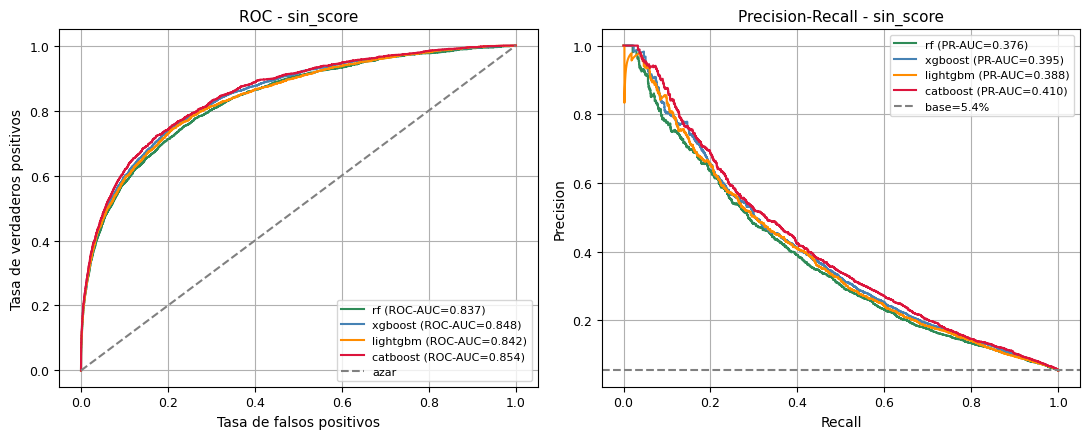

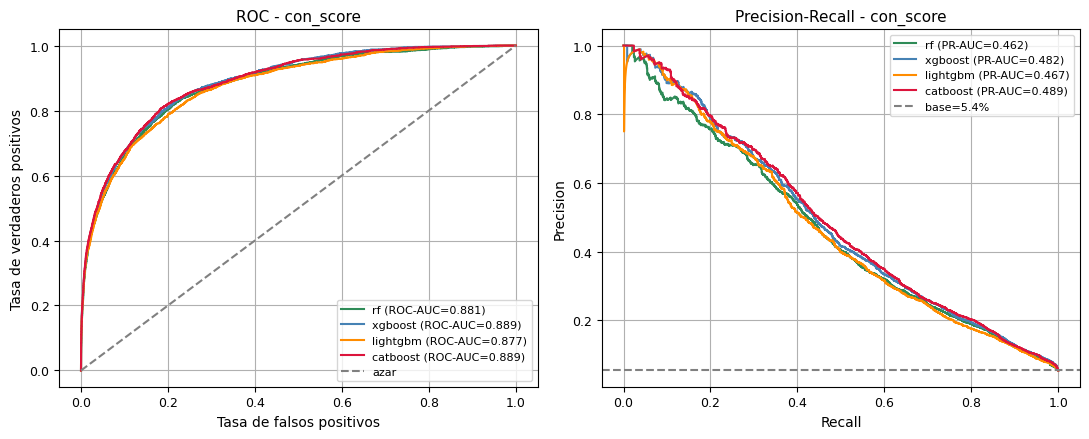

In [12]:
colores_modelo = {
    "rf": "seagreen",
    "xgboost": "steelblue",
    "lightgbm": "darkorange",
    "catboost": "crimson",
}

for escenario in X_por_escenario:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for modelo in MODELOS:
        datos = predicciones_externas.query(
            "modelo == @modelo and escenario == @escenario and repeticion == 0"
        )
        fpr, tpr, _ = roc_curve(datos["target"], datos["probabilidad_fraude"])
        roc = roc_auc_score(datos["target"], datos["probabilidad_fraude"])
        axes[0].plot(
            fpr,
            tpr,
            color=colores_modelo[modelo],
            label=f"{modelo} (ROC-AUC={roc:.3f})",
        )
        precision, recall, _ = precision_recall_curve(
            datos["target"], datos["probabilidad_fraude"]
        )
        pr_auc = auc(recall, precision)
        axes[1].plot(
            recall,
            precision,
            color=colores_modelo[modelo],
            label=f"{modelo} (PR-AUC={pr_auc:.3f})",
        )

    axes[0].plot([0, 1], [0, 1], ls="--", color="gray", label="azar")
    tasa_base = datos["target"].mean()
    axes[1].axhline(tasa_base, ls="--", color="gray", label=f"base={tasa_base:.1%}")
    axes[0].set_title(f"ROC - {escenario}", fontsize=11)
    axes[1].set_title(f"Precision-Recall - {escenario}", fontsize=11)
    axes[0].set_xlabel("Tasa de falsos positivos")
    axes[0].set_ylabel("Tasa de verdaderos positivos")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    for ax in axes:
        ax.legend(fontsize=8)
        ax.tick_params(labelsize=9)
    plt.tight_layout()
    plt.show()

## 7. Comprobación de calibración

Ajusto un calibrador sigmoide con predicciones fuera de muestra de los folds internos y lo aplico al fold externo. Luego comparo Brier y ganancia antes y después al mismo umbral de 0,20.

La calibración se realiza después de Optuna y de la misma forma para todos los modelos, sin usar la validación externa.

In [13]:
resultados_calibracion = []
predicciones_calibradas = []

for outer_fold in FOLDS_EXTERNOS:
    folds_internos = folds.query("fold < @outer_fold")

    for escenario, X in X_por_escenario.items():
        for nombre in MODELOS:
            params = mejores_params[(nombre, escenario, outer_fold)]
            predicciones_internas = []

            for _, fold_interno in folds_internos.iterrows():
                train_interno, val_interna = mascaras_fold(fecha, fold_interno)
                prob_interna = ajustar_y_predecir_arbol(
                    nombre,
                    params,
                    X.loc[train_interno],
                    y.loc[train_interno],
                    X.loc[val_interna],
                    semilla=RANDOM_SEED,
                )
                predicciones_internas.append(pd.DataFrame({
                    "target": y.loc[val_interna].to_numpy(),
                    "monto": monto.loc[val_interna].to_numpy(),
                    "probabilidad": prob_interna,
                }))

            internas = pd.concat(predicciones_internas, ignore_index=True)
            calibrador = ajustar_calibrador_sigmoide(
                internas["probabilidad"], internas["target"]
            )
            externas = predicciones_externas.query(
                "outer_fold == @outer_fold and modelo == @nombre and escenario == @escenario"
            ).copy()
            externas["probabilidad_calibrada"] = aplicar_calibrador(
                calibrador, externas["probabilidad_fraude"]
            )
            externas["aprobar_calibrado_020"] = (
                externas["probabilidad_calibrada"] < UMBRAL_ECONOMICO
            )
            ganancia_si_aprueba = ganancia_por_operacion(
                externas["target"], externas["monto"]
            )
            externas["ganancia_calibrada_020"] = np.where(
                externas["aprobar_calibrado_020"], ganancia_si_aprueba, 0.0
            )
            predicciones_calibradas.append(externas)

            for repeticion, externas_rep in externas.groupby("repeticion"):
                fila = {
                    "outer_fold": outer_fold,
                    "modelo": nombre,
                    "escenario": escenario,
                    "repeticion": repeticion,
                    "ganancia_raw_020": metricas_decision(
                        externas_rep["target"],
                        externas_rep["monto"],
                        externas_rep["probabilidad_fraude"] < UMBRAL_ECONOMICO,
                    )["ganancia"],
                    "ganancia_calibrada_020": metricas_decision(
                        externas_rep["target"],
                        externas_rep["monto"],
                        externas_rep["aprobar_calibrado_020"],
                    )["ganancia"],
                    "brier_raw": metricas_probabilidad(
                        externas_rep["target"],
                        externas_rep["probabilidad_fraude"],
                    )["brier"],
                    "brier_calibrado": metricas_probabilidad(
                        externas_rep["target"],
                        externas_rep["probabilidad_calibrada"],
                    )["brier"],
                }
                resultados_calibracion.append(fila)

resultados_calibracion = pd.DataFrame(resultados_calibracion)
predicciones_calibradas = pd.concat(predicciones_calibradas, ignore_index=True)
resultados_calibracion

,outer_fold,modelo,escenario,repeticion,ganancia_raw_020,ganancia_calibrada_020,brier_raw,brier_calibrado
0,2,rf,sin_score,0,"129,847.6500","129,489.6400",0.0440,0.0435
1,2,rf,sin_score,1,"130,050.0875","127,963.9700",0.0439,0.0434
2,2,rf,sin_score,2,"131,133.2325","129,841.8575",0.0439,0.0434
3,2,xgboost,sin_score,0,"133,698.9825","132,830.9875",0.0420,0.0423
4,2,xgboost,sin_score,1,"132,063.8675","132,525.5400",0.0421,0.0424
5,2,xgboost,sin_score,2,"132,737.3325","132,436.3275",0.0420,0.0423
6,2,lightgbm,sin_score,0,"133,985.3250","132,938.4375",0.0423,0.0429
7,2,lightgbm,sin_score,1,"134,004.1950","132,109.3675",0.0424,0.0430
8,2,lightgbm,sin_score,2,"134,194.0525","131,473.7925",0.0423,0.0430
9,2,catboost,sin_score,0,"131,905.7775","131,567.7625",0.0414,0.0418


In [14]:
calibracion_por_repeticion = (
    resultados_calibracion.groupby(["modelo", "escenario", "repeticion"])
    .agg(
        ganancia_raw_020=("ganancia_raw_020", "sum"),
        ganancia_calibrada_020=("ganancia_calibrada_020", "sum"),
        brier_raw=("brier_raw", "mean"),
        brier_calibrado=("brier_calibrado", "mean"),
    )
    .reset_index()
)

ranking_calibracion = (
    calibracion_por_repeticion.groupby(["modelo", "escenario"])
    .agg(
        ganancia_raw_020=("ganancia_raw_020", "mean"),
        ganancia_calibrada_020=("ganancia_calibrada_020", "mean"),
        brier_raw=("brier_raw", "mean"),
        brier_calibrado=("brier_calibrado", "mean"),
    )
    .assign(
        cambio_ganancia=lambda d: (
            d["ganancia_calibrada_020"] - d["ganancia_raw_020"]
        ),
        cambio_brier=lambda d: d["brier_calibrado"] - d["brier_raw"],
    )
    .sort_values(["escenario", "ganancia_raw_020"], ascending=[True, False])
)
ranking_calibracion

,,ganancia_raw_020,ganancia_calibrada_020,brier_raw,brier_calibrado,cambio_ganancia,cambio_brier
modelo,escenario,,,,,,
lightgbm,con_score,"307,575.7083","306,328.3508",0.0380,0.0383,"-1,247.3575",0.0002
catboost,con_score,"305,632.9258","305,944.8975",0.0371,0.0372,311.9717,0.0001
xgboost,con_score,"305,045.8792","304,518.9842",0.0375,0.0374,-526.8950,-0.0001
rf,con_score,"302,933.8758","302,899.0517",0.0381,0.0381,-34.8242,-0.0001
catboost,sin_score,"297,380.1075","297,717.8183",0.0402,0.0404,337.7108,0.0002
rf,sin_score,"295,722.8150","294,758.2883",0.0421,0.0418,-964.5267,-0.0003
lightgbm,sin_score,"295,498.1025","294,071.8442",0.0413,0.0415,"-1,426.2583",0.0002
xgboost,sin_score,"290,983.0442","291,215.2242",0.0410,0.0411,232.1800,0.0001


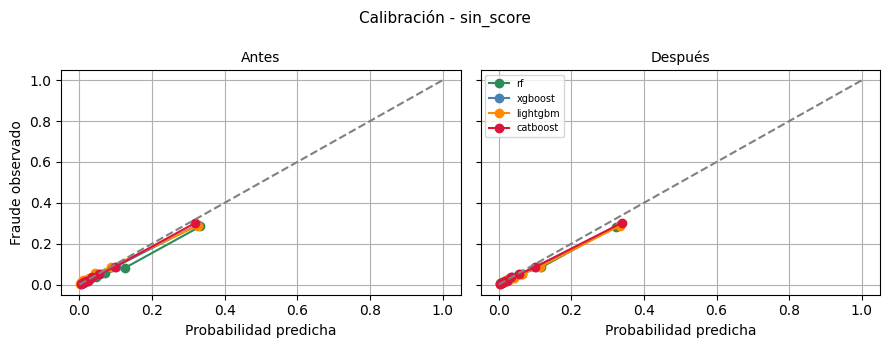

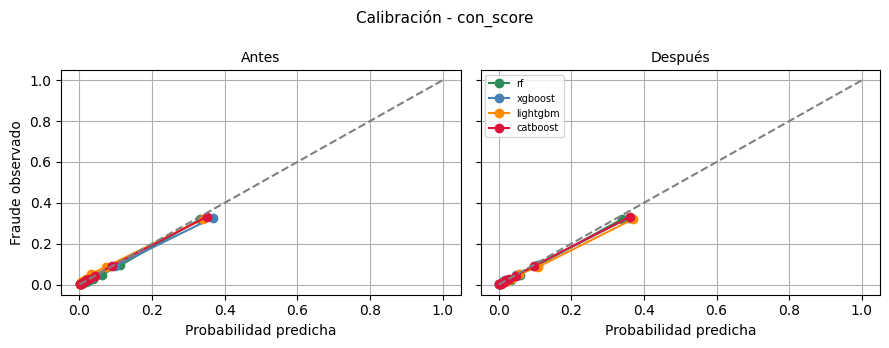

In [15]:
for escenario in X_por_escenario:
    datos_escenario = predicciones_calibradas.query("escenario == @escenario")
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), sharex=True, sharey=True)

    for modelo in MODELOS:
        datos = datos_escenario.query("modelo == @modelo")
        for ax, columna, titulo in zip(
            axes,
            ["probabilidad_fraude", "probabilidad_calibrada"],
            ["Antes", "Después"],
        ):
            observado, predicho = calibration_curve(
                datos["target"], datos[columna], n_bins=10, strategy="quantile"
            )
            ax.plot(
                predicho, observado, marker="o",
                color=colores_modelo[modelo], label=modelo,
            )

    for ax, titulo in zip(axes, ["Antes", "Después"]):
        ax.plot([0, 1], [0, 1], ls="--", color="gray")
        ax.set_title(titulo, fontsize=10)
        ax.set_xlabel("Probabilidad predicha")
    axes[0].set_ylabel("Fraude observado")
    axes[1].legend(fontsize=7)
    fig.suptitle(f"Calibración - {escenario}", fontsize=11)
    plt.tight_layout()
    plt.show()

Los modelos obtienen Brier entre 0,037 y 0,042 y Brier Skill Score positivo en todos los casos. Al aplicar calibración sigmoide, Brier cambia como máximo 0,0003 y la ganancia menos de 1.500, sin una dirección consistente.

Como la recalibración no aporta una mejora estable, continúo con las probabilidades originales. La siguiente sección prueba por separado el efecto de reponderar clases.

### 7.1. Reponderar y recalibrar

Pruebo **scale_pos_weight**, calculado en cada train como la razón entre operaciones legítimas y fraudes, cercana a 18. Lo aplico en CatBoost y XGBoost con los parámetros ya elegidos. Comparo el modelo base, el reponderado crudo y el reponderado recalibrado con folds internos.

Como la recalibración es monótona, ROC-AUC y PR-AUC muestran si cambia el ordenamiento. Brier y ganancia muestran el efecto sobre la escala y la decisión al 0,20.

In [16]:
ESCENARIO_REWEIGHT = "con_score"
MODELOS_REWEIGHT = ["catboost", "xgboost"]
peso_balanceado = lambda mask: int((y.loc[mask] == 0).sum()) / int(y.loc[mask].sum())

filas_reweight = []
for outer_fold in FOLDS_EXTERNOS:
    fold = folds.loc[folds["fold"].eq(outer_fold)].iloc[0]
    train, validacion = mascaras_fold(fecha, fold)
    y_val = y.loc[validacion]
    monto_val = monto.loc[validacion]
    peso = peso_balanceado(train)
    folds_internos = folds.query("fold < @outer_fold")
    X = X_por_escenario[ESCENARIO_REWEIGHT]

    for nombre in MODELOS_REWEIGHT:
        params = mejores_params[(nombre, ESCENARIO_REWEIGHT, outer_fold)]

        # Calibrador del modelo reponderado: predicciones OOF internas, tambien reponderadas.
        internas = []
        for _, fold_interno in folds_internos.iterrows():
            train_int, val_int = mascaras_fold(fecha, fold_interno)
            prob_int = ajustar_y_predecir_arbol(
                nombre, params, X.loc[train_int], y.loc[train_int], X.loc[val_int],
                semilla=RANDOM_SEED, peso_positivo=peso_balanceado(train_int),
            )
            internas.append(pd.DataFrame({
                "target": y.loc[val_int].to_numpy(),
                "probabilidad": np.asarray(prob_int),
            }))
        internas = pd.concat(internas, ignore_index=True)
        calibrador = ajustar_calibrador_sigmoide(internas["probabilidad"], internas["target"])

        for semilla in SEMILLAS_EVALUACION:
            prob_base = ajustar_y_predecir_arbol(
                nombre, params, X.loc[train], y.loc[train], X.loc[validacion], semilla=semilla,
            )
            prob_reweight = ajustar_y_predecir_arbol(
                nombre, params, X.loc[train], y.loc[train], X.loc[validacion],
                semilla=semilla, peso_positivo=peso,
            )
            prob_reweight_cal = pd.Series(
                aplicar_calibrador(calibrador, prob_reweight), index=prob_reweight.index,
            )

            for variante, probabilidad in [
                ("base", prob_base),
                ("reweight_crudo", prob_reweight),
                ("reweight_recalibrado", prob_reweight_cal),
            ]:
                aprobar = probabilidad < UMBRAL_ECONOMICO
                fila = {
                    "modelo": nombre, "outer_fold": outer_fold,
                    "semilla": semilla, "variante": variante,
                }
                fila.update(metricas_decision(y_val, monto_val, aprobar))
                fila.update(metricas_probabilidad(y_val, probabilidad))
                filas_reweight.append(fila)

resultados_reweight = pd.DataFrame(filas_reweight)

# Ganancia: se suma sobre folds y se promedia entre semillas. El ordenamiento (ROC, PR-AUC
# normalizado) es invariante a la recalibracion, asi que decide la comparacion.
reweight_por_semilla = (
    resultados_reweight.groupby(["modelo", "variante", "semilla"])
    .agg(
        ganancia=("ganancia", "sum"),
        roc_auc=("roc_auc", "mean"),
        pr_auc_norm=("pr_auc_norm", "mean"),
        brier=("brier", "mean"),
        tasa_aprobacion=("tasa_aprobacion", "mean"),
    )
    .reset_index()
)
orden_variantes = ["base", "reweight_crudo", "reweight_recalibrado"]
resumen_reweight = (
    reweight_por_semilla.groupby(["modelo", "variante"])
    .agg(
        ganancia=("ganancia", "mean"),
        ruido_semillas=("ganancia", "std"),
        roc_auc=("roc_auc", "mean"),
        pr_auc_norm=("pr_auc_norm", "mean"),
        brier=("brier", "mean"),
        tasa_aprobacion=("tasa_aprobacion", "mean"),
    )
    .reindex(pd.MultiIndex.from_product(
        [MODELOS_REWEIGHT, orden_variantes], names=["modelo", "variante"]))
)
resumen_reweight

ganancia  ruido_semillas  roc_auc  \
modelo   variante                                                     
catboost base                 305,793.9900      1,581.2871   0.8885   
         reweight_crudo       218,048.4500      4,358.7862   0.8797   
         reweight_recalibrado 302,999.8500      3,131.5741   0.8797   
xgboost  base                 305,045.8792        845.4848   0.8877   
         reweight_crudo       214,829.8650      1,974.2057   0.8651   
         reweight_recalibrado 272,266.4958        427.9590   0.8651   

                               pr_auc_norm  brier  tasa_aprobacion  
modelo   variante                                                   
catboost base                       0.4572 0.0371           0.9373  
         reweight_crudo             0.4375 0.0984           0.6254  
         reweight_recalibrado       0.4375 0.0380           0.9227  
xgboost  base                       0.4520 0.0375           0.9277  
         reweight_crudo             0.2150 0.1165           0.6328  
         reweight_recalibrado       0.2150 0.0476           0.9518

La recalibración corrige la escala y recupera gran parte de la ganancia, pero no el ordenamiento. PR-AUC normalizado baja de 0,457 a 0,438 en CatBoost y de 0,452 a 0,215 en XGBoost.

La ganancia recalibrada de CatBoost queda dentro de la variación entre semillas y XGBoost por debajo de la base. Como no aparece una mejora, descarto **scale_pos_weight**.

## 8. Categorías de j no vistas

Con las predicciones existentes de la semilla 42, separo las operaciones entre categorías de j conocidas y nuevas. Estas últimas representan sólo 2-3% de validación, por lo que el análisis es descriptivo y no se usa para seleccionar modelos.

In [17]:
predicciones_unseen = predicciones_externas.query("repeticion == 0").copy()
predicciones_unseen["grupo_j"] = np.where(
    predicciones_unseen["j_nueva"], "j_nueva", "j_conocida"
)

resumen_unseen = (
    predicciones_unseen.groupby(["modelo", "escenario", "grupo_j"])
    .agg(
        n=("target", "size"),
        tasa_fraude=("target", "mean"),
        tasa_aprobacion=("aprobar", "mean"),
        ganancia=("ganancia_realizada", "sum"),
    )
)
resumen_unseen

n  tasa_fraude  tasa_aprobacion  \
modelo   escenario grupo_j                                           
catboost con_score j_conocida  43007       0.0545           0.9382   
                   j_nueva      1046       0.0373           0.9637   
         sin_score j_conocida  43007       0.0545           0.9341   
                   j_nueva      1046       0.0373           0.9570   
lightgbm con_score j_conocida  43007       0.0545           0.9351   
                   j_nueva      1046       0.0373           0.9751   
         sin_score j_conocida  43007       0.0545           0.9345   
                   j_nueva      1046       0.0373           0.9704   
rf       con_score j_conocida  43007       0.0545           0.9301   
                   j_nueva      1046       0.0373           0.9532   
         sin_score j_conocida  43007       0.0545           0.9149   
                   j_nueva      1046       0.0373           0.9379   
xgboost  con_score j_conocida  43007       0.0545           0.9307   
                   j_nueva      1046       0.0373           0.8614   
         sin_score j_conocida  43007       0.0545           0.9328   
                   j_nueva      1046       0.0373           0.8231   

                                  ganancia  
modelo   escenario grupo_j                  
catboost con_score j_conocida 296,278.9900  
                   j_nueva     10,380.8850  
         sin_score j_conocida 286,651.5450  
                   j_nueva     11,148.2700  
lightgbm con_score j_conocida 295,488.6125  
                   j_nueva     11,188.0325  
         sin_score j_conocida 286,172.4900  
                   j_nueva     11,115.0425  
rf       con_score j_conocida 292,655.3900  
                   j_nueva     10,244.1050  
         sin_score j_conocida 284,393.2975  
                   j_nueva     10,592.7750  
xgboost  con_score j_conocida 297,285.7575  
                   j_nueva      8,630.7200  
         sin_score j_conocida 284,771.1175  
                   j_nueva      8,177.2975

Las 1.046 operaciones con categorías nuevas tienen menos fraude que las conocidas, 3,7% contra 5,5%, y dejan ganancia positiva en todos los modelos. CatBoost aprueba 96% frente a 94% en categorías conocidas, mientras que XGBoost aprueba bastante menos de las nuevas. Por el tamaño del grupo, el resultado es descriptivo.

## 9. Candidatos para la prueba de robustez

La comparación anterior mostró que calibrar no mejora de forma consistente. Por eso esta lectura usa las probabilidades originales.

Para acompañar la ganancia miro ROC-AUC, PR-AUC normalizado y Brier Skill Score. Las dos últimas contextualizan cada fold respecto de su prevalencia y se reportan junto con los valores crudos. LightGBM logra la mayor ganancia, CatBoost queda mejor en ordenamiento y calidad probabilística, y XGBoost muy cerca de ambos. Como solo contamos con dos folds externos y las diferencias son pequeñas, los tres boosting con score pasan a una prueba de sensibilidad a la historia de entrenamiento. Random Forest queda fuera porque no presenta una ventaja propia frente a ellos.

Los escenarios se comparan por separado. CatBoost también continúa sin score porque es el árbol más completo dentro de esa alternativa. No compite contra los modelos que usan score: permite medir qué rendimiento conservaríamos si esa variable no estuviera.

In [18]:
tabla_candidatos = ranking.reset_index().sort_values(
    ["escenario", "ganancia_externa"], ascending=[True, False]
)

candidatos_robustez = pd.DataFrame([
    {"escenario": "con_score", "modelo": "xgboost"},
    {"escenario": "con_score", "modelo": "lightgbm"},
    {"escenario": "con_score", "modelo": "catboost"},
    {"escenario": "sin_score", "modelo": "catboost"},
])

display(tabla_candidatos[[
    "escenario", "modelo", "ganancia_externa", "roc_auc",
    "pr_auc_norm", "brier_skill",
]])
# candidatos_robustez queda disponible para el notebook siguiente.

,escenario,modelo,ganancia_externa,roc_auc,pr_auc_norm,brier_skill
0,con_score,lightgbm,"307,575.7083",0.8776,0.4363,0.2595
1,con_score,catboost,"305,632.9258",0.8886,0.4576,0.2777
2,con_score,xgboost,"305,045.8792",0.8877,0.4520,0.2698
3,con_score,rf,"302,933.8758",0.8807,0.4307,0.2575
4,sin_score,catboost,"297,380.1075",0.8537,0.3767,0.2161
5,sin_score,rf,"295,722.8150",0.8371,0.3422,0.1810
6,sin_score,lightgbm,"295,498.1025",0.8419,0.3533,0.1958
7,sin_score,xgboost,"290,983.0442",0.8480,0.3598,0.2019
